Benjamin Arnold; 09/13/2026; Block 1 Checkpoint-- Custom Oscillator

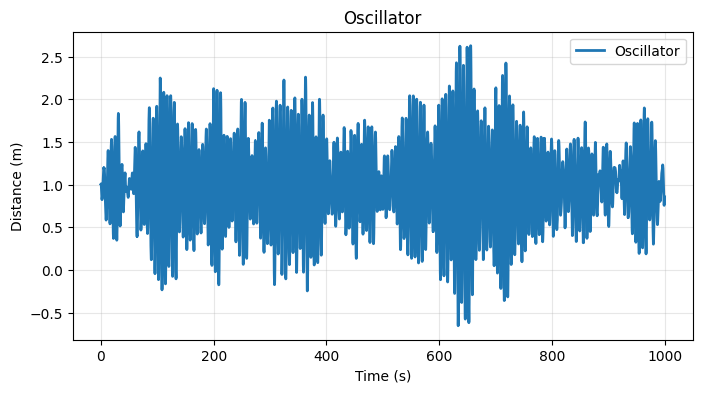

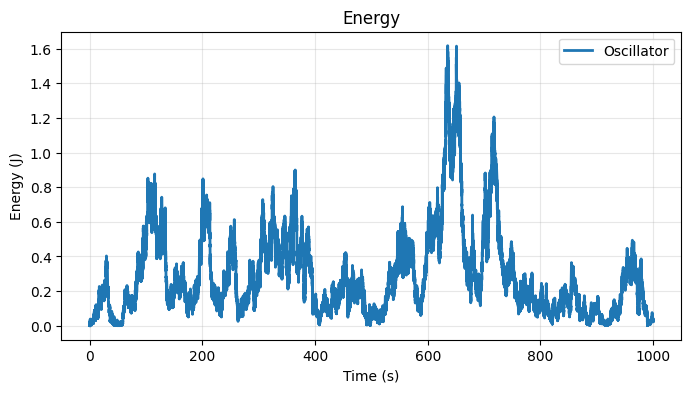

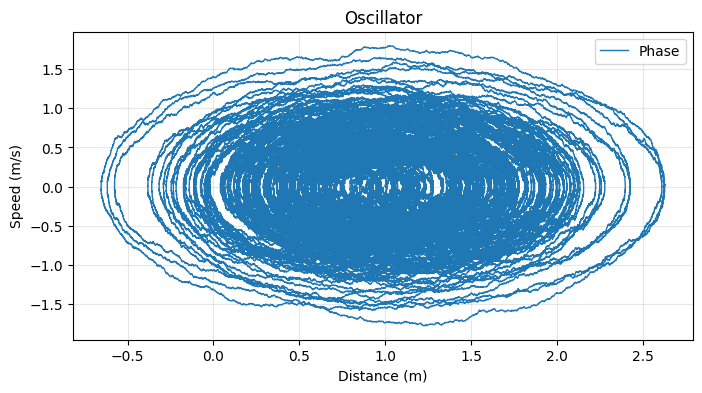

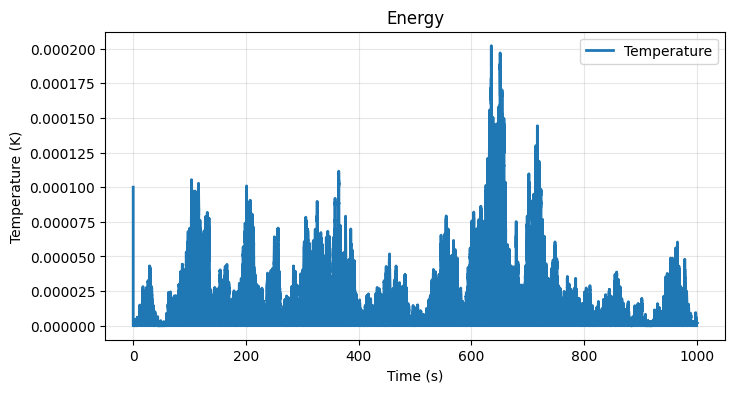

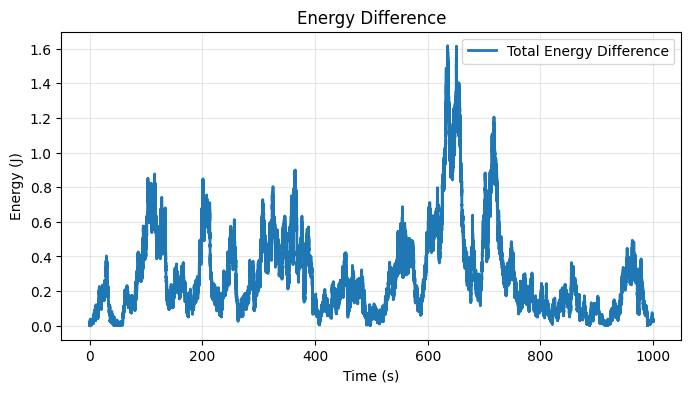

In [50]:
import numpy as np
import matplotlib.pyplot as plt

time_step=0.001
v0=0.0
x0=1.001

m=1.0
eq=1.0
k=1.0
b=0.01
h=8000
T0=0.0001
period=100

rng = np.random.default_rng()
def simulate_sho(method,dt,n_periods):
    v=v0
    x,t=x0,0.0
    T=T0

    KE=(0.5*m)*v**2
    PE=0.5*k*(x-eq)**2
    E=KE+PE
    
    t_arr,x_arr,v_arr,E_arr,T_arr=[t],[x],[v],[E],[T]

    t_max=period*n_periods
    while (t<=t_max):
        if (method==1):
            R=rng.normal(0,1,size=1).item()
            a=-k*(x-eq)-b*v+np.sqrt((2*b*h*T0)/(m*dt))*R
            v=v+a*dt
            x=x+v*dt

            T=KE/h
        elif(method==0):
            a=-k*(x-eq)-b*v
            x=x+v*dt
            v=v+a*dt
            

        KE=(0.5*m)*v**2
        PE=0.5*k*(x-eq)**2
        E=KE+PE

        t=t+dt

        t_arr.append(t)
        x_arr.append(x)
        v_arr.append(v)
        E_arr.append(E)
        T_arr.append(T)
    return t_arr,x_arr,v_arr,E_arr,T_arr

t,x,v,E,T=simulate_sho(1,time_step,10)



plt.figure(figsize=(8, 4))
plt.plot(t, x, linewidth=2, label='Oscillator')
plt.xlabel('Time (s)')
plt.ylabel('Distance (m)')
plt.title('Oscillator')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, E, linewidth=2, label='Oscillator')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(x, v, linewidth=1, label='Phase')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.title('Oscillator')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, T, linewidth=2, label='Temperature')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (K)')
plt.title('Energy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

En=np.array(E)

plt.figure(figsize=(8, 4))
plt.plot(t, (En-En[0]), linewidth=2, label='Total Energy Difference')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy Difference')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

I tried to make a simulation of a bonded particle in a thermal bath. So, the acceleration term includes a modified version of Hooke's Law, a damping or friction term, and then a term that essentially causes random "kicks" according to a normal distribution. The Physics predicts that this circumstance does not blow up, of course, and that these random thermal kicks, denoted Brownian motion, remains relatively stable over time. But because there are thermal kicks, the Energy graph is not going to sit still, so a simple method of chekcing that was out. While I believe some of the distances the particle gets from equilibrium might in reality tear it apart, the energy, as one can see from the Energy Difference graph, does remain around zero-- which makes sense because it starts very near equilibrium in the simulation. I also added a temperature tracker (a thermostat if you will), to see if it explodes in this respect, but as one can see, the situation remains stable there as well.